# Pipeline

One place to run the whole project: configure, collect, inspect, train, probe. Each section is a thin wrapper over code that lives in its own module, so this notebook is orchestration only.

Paths and the active run come from `config.py`. Change `RUN` there to point everything at a different dataset and checkpoint. Hyperparameters are set in the Config cell below and threaded through the rest.

## Config

Every knob (paths, run, seed, collection params, model dims, training hyperparameters) now lives in `config.py`. This cell just imports them. To change a hyperparameter, edit `config.py` and restart the kernel.

In [1]:
import os
# numpy-MKL and torch each bundle their own OpenMP runtime. On conda/Windows the
# two libiomp copies collide and kill the kernel when MKL LAPACK first runs (e.g.
# np.linalg.svd in the latent PCA). This lets them coexist. Must be set before
# torch/numpy import, so it sits at the very top of the first cell.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
from config import (
    DATA_PATH, CKPT_PATH, REPORT_DIR, SEED,
    N_EPISODES, MAX_STEPS, HOLD_K, GRID_SIZE,
    V_MEAN, V_STD, OMEGA_MEAN, OMEGA_STD,
    LATENT_DIM, LR, LAM, EPOCHS, BATCH_SIZE,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
REPORT_DIR.mkdir(parents=True, exist_ok=True)   # results/<RUN>/ for this run's table + figures
print(f"dataset    : {DATA_PATH}")
print(f"checkpoint : {CKPT_PATH}")
print(f"reports    : {REPORT_DIR}")
print(f"device     : {DEVICE}")
print(f"model      : grid={GRID_SIZE} latent={LATENT_DIM}  |  "
      f"train: epochs={EPOCHS} lr={LR} lam={LAM} batch={BATCH_SIZE}")

dataset    : c:\Users\donov\OneDrive\Desktop\PHYSWM\data\datasets\run01_40x40.h5
checkpoint : c:\Users\donov\OneDrive\Desktop\PHYSWM\models\checkpoints\run01_40x40_jepa_long.pt
reports    : c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run01_40x40
device     : cpu
model      : grid=40 latent=128  |  train: epochs=10 lr=0.001 lam=0.01 batch=128


## Collect

Generate the dataset if it does not already exist. Skips straight through when `DATA_PATH` is present so re-running the notebook is cheap. Coverage diagnostics are written next to the dataset.

In [2]:
from data.collect import collect_dataset
from data.coverage import plot_coverage

if DATA_PATH.exists():
    print(f"dataset exists, skipping collection: {DATA_PATH}")
else:
    collect_dataset(DATA_PATH, n_episodes=N_EPISODES, max_steps=MAX_STEPS,
                    hold_k=HOLD_K, grid_size=GRID_SIZE,
                    v_mean=V_MEAN, v_std=V_STD,
                    omega_mean=OMEGA_MEAN, omega_std=OMEGA_STD,
                    seed=SEED)
    plot_coverage(DATA_PATH, show=True)

dataset exists, skipping collection: c:\Users\donov\OneDrive\Desktop\PHYSWM\data\datasets\run01_40x40.h5


## Inspect

Read-back before training. Reports dataset size plus the three diagnostics from `data/diagnostics.py`:

- **frame identity rate**: fraction of consecutive frames that are pixel-identical. Low is good. High means transitions are too redundant to learn from.
- **pixel-change distribution**: how many cells flip per step.
- **theta quantization ceiling**: the smallest rotation that changes a pixel at each resolution. The hard observability floor for heading.

transitions : 114127
episodes    : 3913
grid size   : 40
frame identity rate : 2.08%


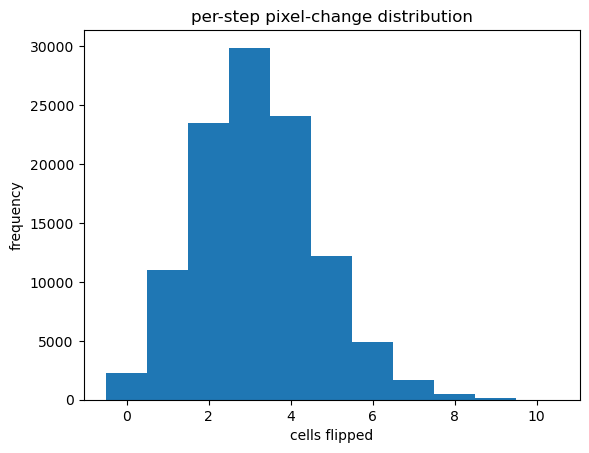


theta quantization ceiling (smallest visible rotation):
40x40:  min=1.0°  mean=5.0°  max=15.0°
64x64:  min=1.0°  mean=2.1°  max=6.0°
84x84:  min=1.0°  mean=1.5°  max=4.0°


{40: {'mean_deg': 4.971830985915492,
  'min_deg': 0.9999999999999887,
  'max_deg': 15.000000000000009,
  'flip_angles': array([-3.07177948, -3.00196631, -2.87979327, -2.70526034, -2.63544717,
         -2.61799388, -2.565634  , -2.54818071, -2.47836754, -2.21656815,
         -2.14675498, -2.12930169, -2.07694181, -2.05948852, -1.98967535,
         -1.81514242, -1.69296937, -1.6231562 , -1.50098316, -1.43116999,
         -1.30899694, -1.13446401, -1.06465084, -1.04719755, -0.99483767,
         -0.97738438, -0.90757121, -0.64577182, -0.57595865, -0.55850536,
         -0.50614548, -0.48869219, -0.41887902, -0.2443461 , -0.12217305,
         -0.05235988,  0.06981317,  0.13962634,  0.26179939,  0.43633231,
          0.50614548,  0.52359878,  0.57595865,  0.59341195,  0.66322512,
          0.9250245 ,  0.99483767,  1.01229097,  1.06465084,  1.08210414,
          1.15191731,  1.32645023,  1.44862328,  1.51843645,  1.6406095 ,
          1.71042267,  1.83259571,  2.00712864,  2.07694181,  2.0943

In [3]:
import matplotlib.pyplot as plt
from data.diagnostics import (
    load_h5,
    frame_identity_rate,
    pixel_change_distribution,
    theta_quantization_ceiling,
)

d = load_h5(DATA_PATH)
print(f"transitions : {d['actions'].shape[0]}")
print(f"episodes    : {len(d['episode_lengths'])}")
print(f"grid size   : {int(d['attrs']['grid_size'])}")

# fraction of consecutive frames that are pixel-identical (low is good)
rate = frame_identity_rate(d["frames"], d["episode_starts"], d["episode_lengths"])
print(f"frame identity rate : {rate:.2%}")

# per-step pixel-change distribution
_, ax = plt.subplots()
pixel_change_distribution(d["frames"], d["episode_starts"], d["episode_lengths"], ax=ax)
plt.show()

# heading observability floor per resolution
print("\ntheta quantization ceiling (smallest visible rotation):")
theta_quantization_ceiling()

## Train

Build the JEPA and train it, saving the best-val checkpoint to `CKPT_PATH`. `torch.manual_seed(SEED)` makes weight init reproducible. The collapse monitor (right panel of the curve) should hold near 1.

In [4]:
from models.jepa import JEPA
from models.dataset import make_dataloaders
from models.train import train_jepa, plot_history

torch.manual_seed(SEED)
train_dl, val_dl = make_dataloaders(DATA_PATH, batch_size=BATCH_SIZE, seed=SEED)
model = JEPA(grid_size=GRID_SIZE, latent_dim=LATENT_DIM)

history = train_jepa(model, train_dl, val_dl, epochs=EPOCHS, lr=LR, lam=LAM,
                     device=DEVICE, save_best_to=CKPT_PATH)
plot_history(history, save_to=REPORT_DIR / "training_curve.png")

  step    50  total 0.1054  pred 0.0797  sigreg 2.5632  latent_std 0.993
  step   100  total 0.0858  pred 0.0644  sigreg 2.1404  latent_std 0.986
  step   150  total 0.1077  pred 0.0878  sigreg 1.9804  latent_std 0.989
  step   200  total 0.1131  pred 0.0931  sigreg 1.9969  latent_std 0.993
  step   250  total 0.1063  pred 0.0889  sigreg 1.7430  latent_std 0.996
  step   300  total 0.0774  pred 0.0563  sigreg 2.1086  latent_std 1.000
  step   350  total 0.1107  pred 0.0905  sigreg 2.0165  latent_std 0.994
  step   400  total 0.1140  pred 0.0920  sigreg 2.1963  latent_std 1.006
  step   450  total 0.1107  pred 0.0893  sigreg 2.1456  latent_std 1.004
  step   500  total 0.0956  pred 0.0746  sigreg 2.1019  latent_std 1.002
  step   550  total 0.1238  pred 0.0979  sigreg 2.5890  latent_std 1.002
  step   600  total 0.0788  pred 0.0520  sigreg 2.6791  latent_std 1.019
  step   650  total 0.0875  pred 0.0597  sigreg 2.7736  latent_std 1.016
  step   700  total 0.0871  pred 0.0588  sigreg 2.8

KeyboardInterrupt: 

## Probe

Freeze the trained encoder and fit linear + MLP probes to read `(x, y, theta)` out of the latent. Compare against the chance baseline: a probe that beats chance means the encoder learned physical state from pixels alone. Same `SEED` as training, so the probe's val episodes are the held-out ones.

In [ ]:
from eval.probe import run_probe

results = run_probe(ckpt_path=CKPT_PATH, latent_dim=LATENT_DIM,
                    batch_size=256, device=DEVICE, seed=SEED,
                    save_dir=REPORT_DIR)

loaded c:\Users\donov\OneDrive\Desktop\PHYSWM\models\checkpoints\run03_128x128_jepa.pt
latents: 99310 train, 10904 val  (dim 128)
probe               pos_rmse           x_rmse           y_rmse    theta_mae_deg theta_median_deg             x_r2             y_r2
----------------------------------------------------------------------------------------------------------------------------------
chance                0.3168           0.2265           0.2214          90.0000          90.0000           0.0000           0.0000
linear                0.0520           0.0360           0.0375          64.4141          52.3918           0.9745           0.9713
mlp                   0.0289           0.0218           0.0189          53.6869          18.8878           0.9906           0.9927
wrote c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run03_128x128\probe_metrics.csv


## Visualize the latent

Two views of the frozen latent, loaded from the best-val checkpoint:

- **PCA view**: the max-variance 2D shadow. SIGReg flattens variance across all dims, so this looks like a blob and the title shows a low explained-variance %. Expected, not a failure.
- **Probe-axes view**: the latent seen through the directions a linear probe decodes. Position panels rebuild the arena; the heading panel should trace a circle. This is where the probe's R2 becomes a picture.

wrote c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run03_128x128\latent_pca.png
wrote c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run03_128x128\latent_probe_axes.png


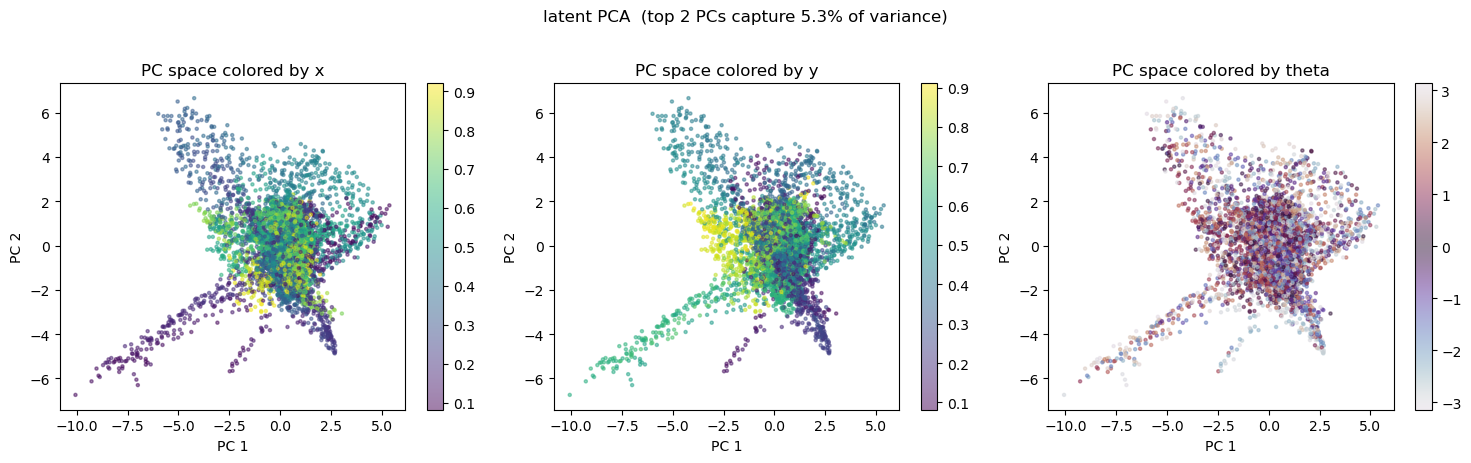

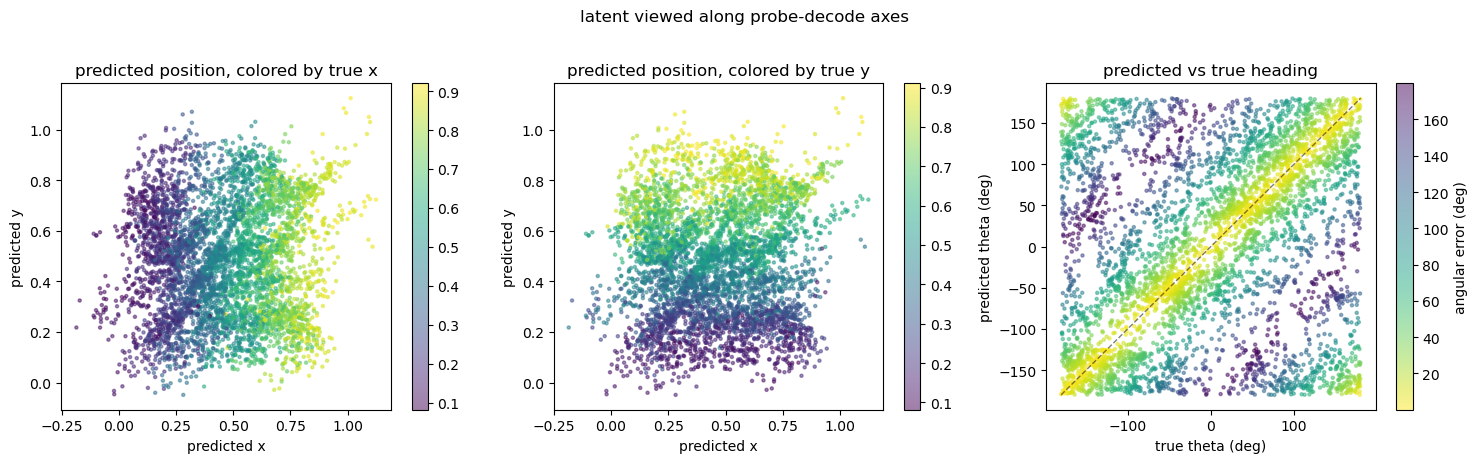

In [ ]:
import matplotlib.pyplot as plt
from models.jepa import JEPA
from models.dataset import make_dataloaders
from eval.probe import extract_latents, plot_latent_pca, plot_latent_probe_axes

# Load the best-val checkpoint (same one the probe scored) and extract val latents.
_, val_dl = make_dataloaders(DATA_PATH, batch_size=256, seed=SEED, return_state=True)
viz_model = JEPA(grid_size=GRID_SIZE, latent_dim=LATENT_DIM)
viz_model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
Z_val, S_val = extract_latents(viz_model, val_dl, DEVICE)

plot_latent_pca(Z_val, S_val, save_to=REPORT_DIR / "latent_pca.png")
plot_latent_probe_axes(Z_val, S_val, save_to=REPORT_DIR / "latent_probe_axes.png")
plt.show()

## Reconstruct

Turn latents back into pixels, two ways, both saved to `results/<RUN>/`:

- **deconv decoder** (`reconstructions.png`): trains a small decoder on the frozen encoder. Grayscale, so blur shows where the model is uncertain.
- **render-based** (`pose_reconstructions.png`): decode the latent to `(x, y, theta)` with a probe, then draw with the simulator. Crisp triangles, and a heading flip shows as a flipped arrow. The `pred next` column tests the predictor, not the encoder.

In [ ]:
import matplotlib.pyplot as plt
from models.jepa import JEPA
from models.dataset import make_dataloaders
from eval.reconstruct import train_decoder, plot_reconstructions, plot_pose_reconstructions

recon_train_dl, recon_val_dl = make_dataloaders(DATA_PATH, batch_size=BATCH_SIZE, seed=SEED, return_state=True)
recon_model = JEPA(grid_size=GRID_SIZE, latent_dim=LATENT_DIM)
recon_model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

# learned deconv decoder: grayscale, blur shows uncertainty
decoder = train_decoder(recon_model, recon_train_dl, epochs=5, device=DEVICE)
plot_reconstructions(recon_model, decoder, recon_val_dl, n=6, device=DEVICE,
                     save_to=REPORT_DIR / "reconstructions.png")

# render-based: decode to pose, draw with the simulator (crisp; heading flips visible)
plot_pose_reconstructions(recon_model, recon_val_dl, n=6, device=DEVICE,
                          save_to=REPORT_DIR / "pose_reconstructions.png")
plt.show()